# Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [114]:
# load dataset
data = sns.load_dataset('mpg')
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [115]:
data.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [116]:
# horsepower null value replace with mean
data['horsepower']=data['horsepower'].fillna(data.horsepower.mean())

In [117]:
data.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [118]:
data.drop(['origin','name'], axis=1, inplace=True)

In [119]:
data.head(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70


# simple linear Regression

<Axes: xlabel='mpg', ylabel='horsepower'>

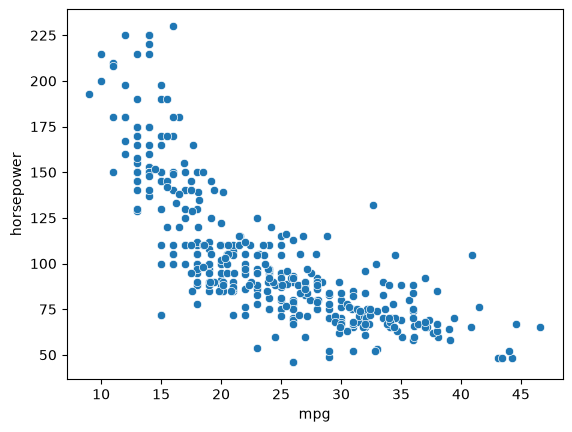

In [120]:
# we take 'horsepower' as input and 'mpg' as target
sns.scatterplot(x='mpg', y='horsepower', data=data)

In [121]:
# Crate X and y
X = data[['horsepower']]
y=data['mpg']

In [122]:
X

,horsepower
0,130.0
1,165.0
2,150.0
3,150.0
4,140.0
...,...
393,86.0
394,52.0
395,84.0
396,79.0


In [123]:
y

0      18.0
1      15.0
2      18.0
3      16.0
4      17.0
       ... 
393    27.0
394    44.0
395    32.0
396    28.0
397    31.0
Name: mpg, Length: 398, dtype: float64

In [124]:
# create train and test dataset
from sklearn.model_selection import train_test_split

In [125]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2, random_state=42)

In [126]:
# Use LinearRegression
from sklearn.linear_model import LinearRegression

In [127]:
# create a model
lr = LinearRegression()
lr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [128]:
# fit the model / train the model
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.16]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['horsepower']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,40.49
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [129]:
# predict the model using X_test
y_pred = lr.predict(X_test)
y_pred

array([31.82781156, 27.57934494, 24.14789114, 15.97776302, 15.97776302,
       26.10872188, 25.45511163,  5.35659647, 22.51386551, 23.41758172,
        9.44166053, 29.54017569, 29.049968  , 15.97776302, 28.23295519,
       11.07568615, 26.59892957, 20.06282708, 11.07568615, 29.37677313,
       28.06955263, 24.96490395, 22.18706039, 26.92573469, 19.24581427,
       31.99121413, 25.78191676, 26.10872188, 20.87983989, 13.19991946,
       26.43552701, 28.39635776, 20.06282708, 24.96490395, 29.86698082,
        2.90555804, 23.0040732 , 16.79477583, 15.97776302, 26.92573469,
       21.6968527 , 30.68399363, 22.18706039,  5.35659647, 24.63809882,
       26.10872188, 28.23295519, 21.6968527 , 24.96490395, 28.88656544,
       28.72316288, 29.86698082, 28.72316288,  9.44166053, 22.51386551,
       11.89269896, 15.97776302, 25.78191676, 25.78191676, 24.96490395,
       11.07568615, 31.82781156, 26.92573469, 26.27212445, 24.96490395,
       24.96490395, 26.59892957, 29.86698082, 30.68399363, 19.24

In [130]:
# see the metrices
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [131]:
ms = mean_squared_error(y_pred,y_test)
ma = mean_absolute_error(y_pred,y_test)
rs = r2_score(y_test,y_pred)

In [132]:
print("SimpleLinearRegression model")
print("mean squared error:",ms)
print("mean absolute error:",ma)
print("r2 score: ",rs)

SimpleLinearRegression model
mean squared error: 19.151211313552405
mean absolute error: 3.4834646156800146
r2 score:  0.6438073642623536


In [133]:
# r2 score is 64% only which is not good accuracy
# here, we use only one input, to predict the output, although we have multiple inputs.
# plot the regression line and data

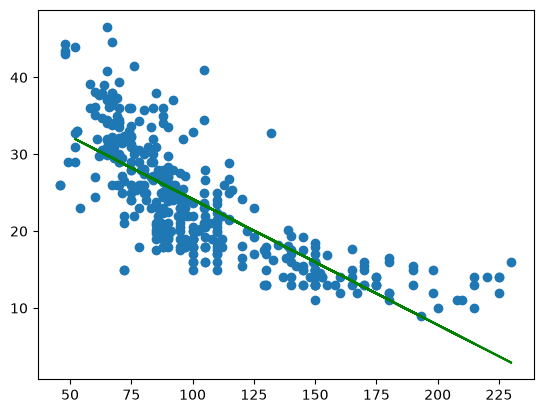

In [134]:
plt.scatter(X,y)
plt.plot(X_test,y_pred, color='green')



# Multiple Linear Regression

In [135]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


In [136]:
X = data.drop('mpg', axis=1)
y = data['mpg']

In [137]:
X

,cylinders,displacement,horsepower,weight,acceleration,model_year
0,8,307.0,130.0,3504,12.0,70
1,8,350.0,165.0,3693,11.5,70
2,8,318.0,150.0,3436,11.0,70
3,8,304.0,150.0,3433,12.0,70
4,8,302.0,140.0,3449,10.5,70
...,...,...,...,...,...,...
393,4,140.0,86.0,2790,15.6,82
394,4,97.0,52.0,2130,24.6,82
395,4,135.0,84.0,2295,11.6,82
396,4,120.0,79.0,2625,18.6,82


In [138]:
y

0      18.0
1      15.0
2      18.0
3      16.0
4      17.0
       ... 
393    27.0
394    44.0
395    32.0
396    28.0
397    31.0
Name: mpg, Length: 398, dtype: float64

In [139]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [140]:
lr = LinearRegression()

In [141]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0.07, 0. , 0. ,-0.01, 0.08, 0.8 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['cylinders','displacement','horsepower','weight','acceleration', 'model_year']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-18.68
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [142]:
# predit
y_pred=lr.predict(X_test)
y_pred

array([31.53109579, 30.70849255, 21.76226   , 17.00367581, 12.6130019 ,
       26.21298858, 28.91110402,  9.203019  , 17.21958478, 22.74890141,
       12.68127025, 34.98788977, 26.69305024, 14.05845246, 24.77721826,
        5.90349606, 30.87237625, 23.812746  , 15.88074362, 35.1630653 ,
       23.44503249, 19.69097766, 29.32850815, 30.33475799, 15.09790363,
       34.56140773, 25.77970744, 25.76026735, 22.17155643,  7.92248019,
       29.35879131, 34.94809283, 20.00733969, 24.92500913, 33.10362116,
       12.27718714, 24.47963851, 22.19709231, 12.37774229, 26.9653782 ,
       27.64455572, 27.40742955, 20.29321008,  7.75458288, 23.2567278 ,
       33.67959269, 26.58280382, 24.46965565, 22.78493184, 27.69250537,
       23.46866786, 32.51641698, 31.29673875, 10.59203038, 29.0331764 ,
        9.37415973, 19.459108  , 28.30596417, 24.25237835, 20.74590348,
       16.50177291, 30.73792699, 24.91739479, 20.29843339, 21.63449641,
       24.35609011, 25.87130899, 33.72516256, 29.33902158, 12.67

In [143]:
# check metric / accuracy
ms = mean_squared_error(y_pred,y_test)
ma = mean_absolute_error(y_pred,y_test)
rs = r2_score(y_test,y_pred)

In [144]:
print("SimpleLinearRegression model")
print("mean squared error:",ms)
print("mean absolute error:",ma)
print("r2 score: ",rs)

SimpleLinearRegression model
mean squared error: 9.441014238263564
mean absolute error: 2.467266053414027
r2 score:  0.8244069426990219


In [145]:
# r2 score: 83% better than earlier since, here we took all the inputs
# plot the REgression line and data

In [146]:
intercept = lr.intercept_
intercept

np.float64(-18.67765887471341)

In [147]:
# coefficient
coff = lr.coef_
coff

array([ 0.06912753,  0.00161762,  0.00274372, -0.00704049,  0.07985934,
        0.80115473])

In [148]:
# y = mx + c --- for one input
# multiple input
# y = mx1 + mx2 + mx3+........+c -----for multiple input

In [149]:
# since, here multiple input and one output --- we cannot plot in 2D
# we can only plot in 3D

# Multiple Linear Regression with 'tips' dataset

In [150]:
data = sns.load_dataset('tips')
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [151]:
enc_sex = {'Female':0,'Male':1}
data['sex'] = data.sex.map(enc_sex)

In [152]:
# smoker
enc_smoker = {'No':0,'Yes':1}
data['smoker']= data['smoker'].map(enc_smoker)

In [153]:
# day
data.day.unique()

['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, str): ['Thur', 'Fri', 'Sat', 'Sun']

In [154]:
enc_day = {'Sun':1,'Sat':2,'Thur':3,'Fri':4}
data['day']=data['day'].map(enc_day)

In [155]:
# time
data.time.unique()

['Dinner', 'Lunch']
Categories (2, str): ['Lunch', 'Dinner']

In [156]:
enc_time = {'Dinner':1,'Lunch':0}
data['time'] = data['time'].map(enc_time)

In [157]:
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,1,1,2
1,10.34,1.66,1,0,1,1,3
2,21.01,3.50,1,0,1,1,3
3,23.68,3.31,1,0,1,1,2
4,24.59,3.61,0,0,1,1,4


In [158]:
X = data.drop('tip',axis=1)

In [159]:
y = data['tip']

In [160]:
X

,total_bill,sex,smoker,day,time,size
0,16.99,0,0,1,1,2
1,10.34,1,0,1,1,3
2,21.01,1,0,1,1,3
3,23.68,1,0,1,1,2
4,24.59,0,0,1,1,4
...,...,...,...,...,...,...
239,29.03,1,0,2,1,3
240,27.18,0,1,2,1,2
241,22.67,1,1,2,1,2
242,17.82,1,0,2,1,2


In [161]:
y

0      1.01
1      1.66
2      3.50
3      3.31
4      3.61
       ... 
239    5.92
240    2.00
241    2.00
242    1.75
243    3.00
Name: tip, Length: 244, dtype: float64

In [162]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [163]:
lr = LinearRegression()

In [164]:
lr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [165]:
lr.fit(X_test,y_test)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0.1 ,-0.26, 0.28,-0.04, 0.11,-0.04]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['total_bill','sex','smoker','day','time','size']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.029
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [166]:
y_pred=lr.predict(X_test)

In [167]:
y_pred

array([2.66580329, 1.6264819 , 3.10249819, 3.47390627, 2.38549346,
       2.80371284, 3.63619185, 2.05097311, 2.21539942, 2.68962882,
       2.55934293, 1.77899738, 1.87165214, 2.46956829, 1.849948  ,
       2.61945924, 2.64762318, 2.88172872, 2.59783941, 4.49660405,
       2.94305567, 2.71200483, 2.67170741, 1.65945006, 3.3257928 ,
       1.71130024, 1.77346631, 3.74665336, 2.31270198, 5.34675297,
       4.46244746, 1.76565463, 2.39858453, 2.99542415, 2.65712791,
       3.11739285, 2.09910256, 5.26570076, 2.11760604, 3.22863941,
       1.75352008, 2.2508719 , 3.11396409, 2.00647694, 1.86258002,
       1.6054341 , 2.30718609, 2.51994521, 1.30660317])

In [168]:
r2 = r2_score(y_test,y_pred)
r2

0.625274936281063

In [169]:
# r2 score is ony 62% which is very low, not good for ML 

<Axes: xlabel='total_bill', ylabel='tip'>

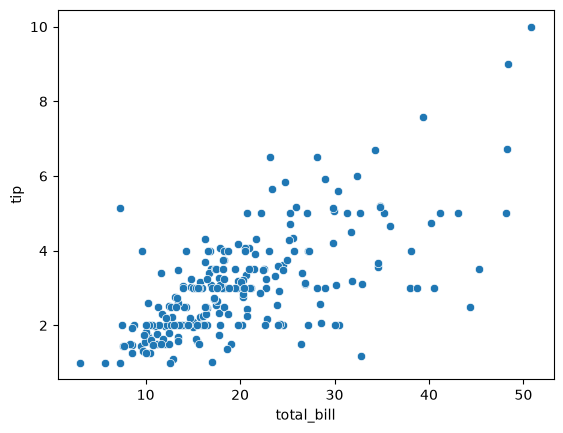

In [170]:
sns.scatterplot(x='total_bill',y='tip', data=data)

In [ ]:
# parameter tuning
# 90% better accuracy else reject the data
